# Notebook de traitement de fichiers NBS en fichiers BNT


Ce Notebook permet de generer un fichier .nbt à partir d'un fichier .nbs provenant du logiciel noteblock studio.

Le layout des noteblock est fixe et ne peut être definis ici. Les paramètres que l'on peut ajuster sont le tempo de la chanson, ainsi que la decoration au niveau du rail.

## imports package

In [16]:
# Imports Generals 
import time
import pandas as pd
from nbt import nbt
import copy
import numpy as np
import math
import random
from random import randint
import matplotlib.pyplot as plt

# Foctions et classes custom
import ReadNBS

from data import Data
from Layout2 import Layout2
#from Layout2 import Layout, AjoutBaseLane
from customNBT import *

## Défionition des paramètres 

On peut definir ci-dessous, le fichier d'entrée (.nbs), le fichier de sortie (.nbt), aisni que le tempo affiché dans noteblock studio. Il est cependant fortement recommandé d'ajuster le tempo à 20 tick/seconde dans un autre notebook afin de verifier qu'il n'y a pas d'artefacts de changmenet de tempo.



par default un tick = 0.1s -> 10 tick/ seondes

On peut changer les tick/seconde en multipliant par un coefitient.

On peut jouer à:
    
    20    tick/seconde , multiplier par 0.5
    6.67 tick/seconde , multiplier par 1.5
    10   tick/seconde , multiplier par 1
    5   tick/seconde , multiplier par 2
    4   tick/seconde , multiplier par 2.5


In [17]:
file ="in/dark aria_8.nbs"
#out = "out/abcdfu.nbt"
tick_s = 20

Chargement et traitement du fichier d'entrée

In [18]:
df = ReadNBS.read_file(file)
data = ReadNBS.PrepData(df, tick_s, 20)

Loading file:  in/dark aria_8.nbs


In [19]:
#data = data.head(30)

## Affichage des paramètres de la chanson d'entreé


On affiche combien on a notes par tick (2 notes peuvent être utilisées par "layout", on a 2 layouts par étages, puis 2 à 3 étages.

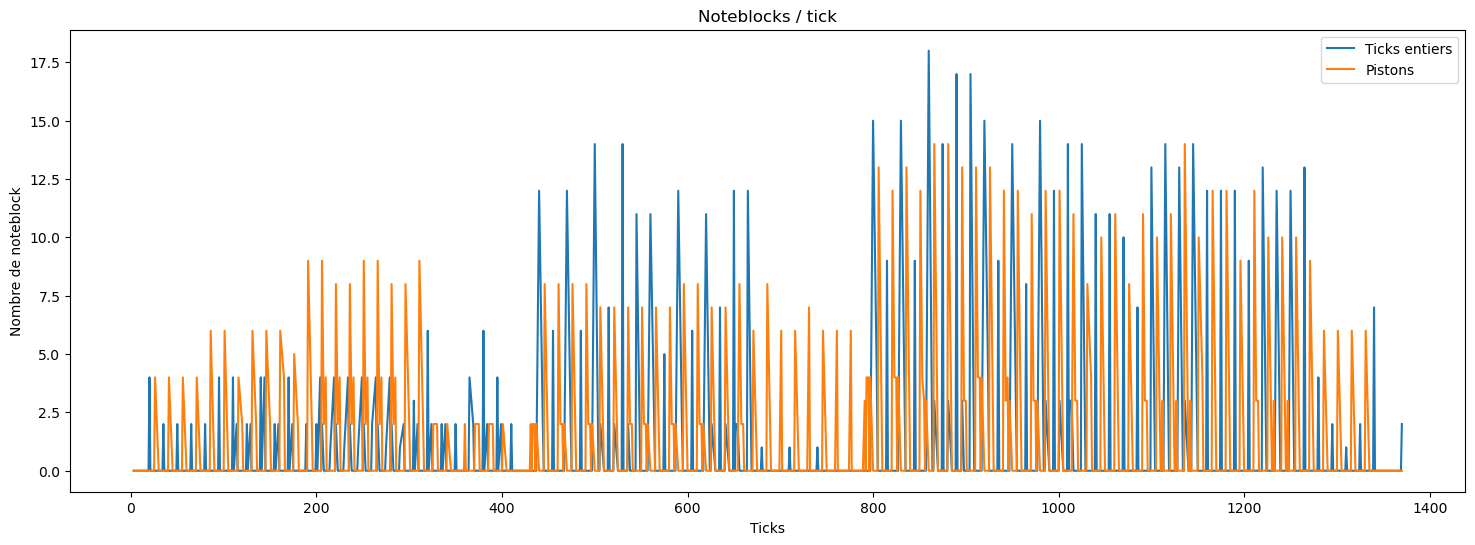

In [20]:
nbEntiers = []
nbPasEntier = []
for i in data.index:
    if(data.loc[i]['note entier'] != None):
        nbEntiers.append(len(data.loc[i]['note entier']))
    else:
        nbEntiers.append(0)
    
    if(data.loc[i]['note demi'] != None):
        nbPasEntier.append(len(data.loc[i]['note demi']))
    else:
        nbPasEntier.append(0)

plt.figure(figsize=(18, 6))
plt.plot(data.index, nbEntiers, label = 'Ticks entiers')
plt.plot(data.index, nbPasEntier, label = 'Pistons')
         
         
plt.title("Noteblocks / tick")
plt.xlabel("Ticks")
plt.ylabel("Nombre de noteblock")
plt.legend()
plt.show()

## On Crée deja les fichiers ntb pour recuperer les indices

In [21]:
dataNBT = Data()
nbtfile = customNBT()


## Definition des blocs de la décoration

In [22]:
# definition de quelque noms de blocs qui peuvent être utilisé pour la décoration

flowers = ['dandelion','poppy','blue_orchid','allium','azure_bluet','red_tulip','pink_tulip','sunflower','rose_bush','peony',
           'oxeye_daisy','cornflower','lily_of_the_valley','wither_rose','sunflower','lilac','rose_bush','torchflower' ]

saplings = ['oak_sapling', 'birch_sapling', 'acacia_sapling']
blocs = ['stone','andesite','cracked_stone_bricks','stone_bricks','light_gray_concrete']
deco = ['lantern', 'chest','soul_lantern','campfire','anvil', 'enchanting_table','furnace','barrel','stonecutter']


bougies = ['candle', 'red_candle','purple_candle', 'lime_candle','orange_candle']
autre_lumiere = ['lantern','end_rod']

blocs_r = ['red_concrete','yellow_concrete', 'orange_concrete', 'pink_concrete','red_concrete',
          'red_wool','yellow_wool', 'orange_wool', 'pink_wool','red_wool','magenta_wool',
          'red_concrete_powder','orange_concrete_powder']


bloc_sol = ['copper_block','exposed_copper','weathered_copper','oxidized_copper','copper_block','exposed_copper','weathered_copper','oxidized_copper','sea_lantern','gold_block', 'diamond_block']


bloc_sol = ['ochre_froglight','pearlescent_froglight','verdant_froglight']
for i in range(50):
    bloc_sol.append('black_concrete')

    
bloc_sol = ['red_concrete','weathered_copper','verdant_froglight','black_concrete']


bloc_sol = ['ochre_froglight','pearlescent_froglight','verdant_froglight']
for i in range(50):
    bloc_sol.append('grass_block')

    
bloc_sol=['cobblestone','stone_bricks','stone']

bloc_sol=['grass_block','grass_block']

    
i_sol = [nbtfile.Index(name) for name in bloc_sol]
i_deco = [nbtfile.Index(name) for name in flowers]
    
    
for i in [1,2,2,3,3,4,4]:    
    i_deco.append(nbtfile.Index('pink_petals',{'flower_amount':str(i)}))



i_deco_volant = [nbtfile.Index(bougie,{'candles':str(1),'lit':'true'}) for bougie in bougies]
#i_deco_volant.append([nbtfile.Index(bougie,{'candles':str(2)}) for bougie in bougies])



## On place tout les blocs necessaire à la musique

In [23]:
# Nouveau layout pour toute la chanson


lastTick = -1
direction = 0

pos = [1,0,0]

for tick in data.index:
           
    tickDiff = tick - lastTick
    layout = Layout2(nbt = nbtfile)
    layout.tick = lastTick
    
    # Supprmier index Sol si necessaire
    layout.indexSol = nbtfile.Index("dark_oak_planks")

    notesEntier = data.loc[tick]['note entier']
    notesDemi = data.loc[tick]['note demi']
    #print(pos[0], pos[2])

    layout.pos[0] = pos[0]
    layout.pos[2] = pos[2]
    layout.data.pos[0] = pos[0]
    layout.data.pos[2] = pos[2]

    if(direction%4 == 0):
            
        layout.Add(tickDiff, notesEntier,notesDemi,True)
        pos[0]+=1
        pos[2]+=-2
    elif(direction%4 == 1):

        layout.Add(tickDiff, notesEntier,notesDemi)
        layout.Flip()
        layout.Rotate(-1)
        pos[0]+=2
        pos[2]+=-1
    elif(direction%4 == 2):

        layout.Add(tickDiff, notesEntier,notesDemi,True)
        layout.Flip()
        pos[0]+=1
        pos[2]+=2

    else:
        layout.Add(tickDiff, notesEntier,notesDemi)
        layout.Rotate(1)        
        pos[0]+=2
        pos[2]+=1

    direction+=1

    dataNBT.AddData(layout.data)

    lastTick = tick
    #print(lastTick)
    #lastTick = tickEntier



In [24]:
def randIndex(variables, probNothing = 0):
    if(random.random()<=probNothing):
        return nbtfile.Index('air')
    return variables[randint(0, len(variables)-1)]

In [25]:
randIndex(i_deco_volant,0.5)

84

In [26]:
nbtfile.Index('air')

90

## On place les blocs de la déco

In [27]:
dataDeco = Data()

lenb = len(bloc_sol)-1
tick_rails = 14
avance  = 5
rd = 5

for i in range(pos[0] + 20):
    tick_equivalent = np.ceil(i*10/8)
    
    # Default 7 - 11 pour du 7-10
    for k in reversed(range(5,-9,-1)):
        # On fait le sol
        #dataDeco.AddBlock(i,-2, k, randIndex(i_sol), tick = tick_equivalent-avance-10, randomAmount = rd)
        dataDeco.AddBlock(i,-1, k, randIndex(i_sol), tick = tick_equivalent-avance-10, randomAmount = rd)
        dataDeco.AddBlock(i,0, k, randIndex(i_deco, 0.1), tick = tick_equivalent-avance, randomAmount = rd,needsDown=True)

    for k in [1,2,3,4,5,-3,-4,-5,-6,-7]:
        pass
        #dataDeco.AddBlock(i,2, k, randIndex(i_deco_volant,0.95), tick = tick_equivalent-avance, randomAmount = rd)
        #dataDeco.AddBlock(i,3, k, randIndex(i_deco_volant,0.95), tick = tick_equivalent-avance, randomAmount = rd)
        #dataDeco.AddBlock(i,4, k, randIndex(i_deco_volant,0.95), tick = tick_equivalent-avance, randomAmount = rd)
        #dataDeco.AddBlock(i,5, k, randIndex(i_deco_volant,0.95), tick = tick_equivalent-avance, randomAmount = rd)
        
    for k in [-9, 6]:
        if(randint(0,10)>3):
            dataDeco.AddBlock(i,-1, k, randIndex(i_sol), tick = tick_equivalent-avance-10, randomAmount = rd)
            dataDeco.AddBlock(i,0, k, randIndex(i_deco, 0.1), tick = tick_equivalent-avance, randomAmount = rd,needsDown=True)
    for k in [-10, 7]:
        if(randint(0,10)>5):
            dataDeco.AddBlock(i,-1, k, randIndex(i_sol), tick = tick_equivalent-avance-10, randomAmount = rd)
            dataDeco.AddBlock(i,0, k, randIndex(i_deco, 0.1), tick = tick_equivalent-avance, randomAmount = rd,needsDown=True)
    for k in [-11, 8]:
        if(randint(0,10)>8):
            dataDeco.AddBlock(i,-1, k, randIndex(i_sol), tick = tick_equivalent-avance-10, randomAmount = rd)
            dataDeco.AddBlock(i,0, k, randIndex(i_deco, 0.1), tick = tick_equivalent-avance, randomAmount = rd,needsDown=True)

    #dataDeco.AddBlock(i,0, -10, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)
    #dataDeco.AddBlock(i,0, 7, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)
    #dataDeco.AddBlock(i,1, -11, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)
    #dataDeco.AddBlock(i,1, 8, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)
    #dataDeco.AddBlock(i,2, -12, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)
    #dataDeco.AddBlock(i,2, 9, nbtfile.Index(bloc_sol[randint(0,lenb)]), tick = tick_equivalent-avance, randomAmount = rd)

    if(i%2==0):
        pass
        #dataDeco.AddBlock(i,3, -1, nbtfile.Index("detector_rail", {'shape' : 'east_west'}), tick = tick_equivalent+tick_rails, randomAmount=0,needsDown=True)
    else:
        pass
        #dataDeco.AddBlock(i,3, -1, nbtfile.Index("powered_rail", {'shape' : 'east_west'}), tick = tick_equivalent+tick_rails, randomAmount=0,needsDown=True)
    
    #dataDeco.AddBlock(i,2, -1, nbtfile.Index("glass"), tick = tick_equivalent+tick_rails, randomAmount=0)

## On fusione les deux ( musqiue et déco) et on creer un premeir ficheir

In [28]:
dataDeco.AddData(dataNBT)
dataNBT = dataDeco

In [29]:
dataNBT.WriteNBT(nbtfile)
nbtfile.write_file('tests/dark2.nbt')

# Pour voir combien de block on a dans le fichier
nbtfile.nbtfile['blocks']

38638 entries of type TAG_Compound

## On definit dans quel "layer" on a les blocs
## On genère d'abord  les object qui contiennent les données

In [18]:
# AJout d'un block de redstone pour lancer automatiquement la chanson au chargement
dataNBT.AddBlock(0,0,0, nbtfile.Index("redstone_block"),5,randomAmount=0)

# precision du chargement des blocs => faire des test a la reduction à 1
tickDelay = 1
dataNBT.SetLayers(5)

t = time.time()
# On ecrit chacun des fichiers nbt
# d'abord on ecrit dans les layers

offsetY = -10
offsetZ = 0

nbLayers = int(max([a[4] for a in dataNBT.data.flatten()]))+1
#int(np.max(dataNBT.data[:,:,:][4]))+1
offsets = [None] * nbLayers

layouts = []
for i in range(nbLayers):
    layouts.append(Data())
    layouts[i].Reshape(0,0,dataNBT.shape[2]-1)


sX = dataNBT.shape[0]
sY = dataNBT.shape[1]
sZ = dataNBT.shape[2]

for i in range(sX):
    for j in range(sY):
        for k in range(sZ):
            i2 = i-sX//2
            j2 = j-sY//2
            k2 = k-sZ//2
           
            if(dataNBT.data[i2,j2,k2][0]):
                
                layer = int(dataNBT.data[i2,j2,k2][4])
                if(offsets[layer] == None):
                    offsets[layer] = i2
                    layouts[layer].pos = [0,0,0]
                
                #offsets[layer] = 0
                
                #offsetStructBlock = layer*3
                #offsets[layer]=0
                layouts[layer].AddBlock(i2-offsets[layer],j2-offsetY,k2-offsetZ, dataNBT.data[i2,j2,k2][1], 0)
                

# do stuff
elapsed = time.time() - t
print(elapsed)

1.3073787689208984


## On genère les fichiers

In [19]:
#Puis on genère le ficheir
t = time.time()                
for i in range(len(layouts)):
    l = layouts[i]
    nbt2 = customNBT()
    nbt2.nbtfile['palette']  = nbtfile.nbtfile['palette']
    l.WriteNBT(nbt2)
    nbt2.write_file('out/test'+str(i*tickDelay)+'.nbt')

elapsed = time.time() - t
print(elapsed)
     

7.229106664657593


# On genière les fichier nbt qui contient la ligne de bloc structure pour lancer la chason

In [20]:
nbtStructures = customNBT()
d = Data()

x = 0
z = 0
x2 = 0
z2  =0

#position = 0
retard = 0
retardEtrange = 0


for i in range(len(layouts)*tickDelay):
    
    
    # on met la direction du repeter & on prépare l'indice du noteblock
    if(i%16 == 0):
        if(retard > 2):
            i_red = nbtStructures.GetIndex("minecraft:redstone_wire")
            retard = min(retard,14)
                
            for j in range(retard-2):
                nbtStructures.AddBloc([x,0+offsetY,z], i_red)
                nbtStructures.AddBloc([x,-1+offsetY,z], nbtStructures.Index('stone'))
                x+=1
        index = nbtStructures.Index("repeater",{'facing':'west', 'delay':str(1) })
        x2 = x+1
        z2 = z
    elif(i%16 <= 7):
        index = nbtStructures.Index("repeater",{'facing':'north', 'delay':str(1) })
        x2 = x
        z2 = z+1
    elif(i%16 == 8):
        index = nbtStructures.Index("repeater",{'facing':'west', 'delay':str(1) })
        x2 = x+1
        z2 = z
    else:
        index = nbtStructures.Index("repeater",{'facing':'south', 'delay':str(1) })
        x2 = x
        z2 = z-1
        
    nbtStructures.AddBloc([x,0+offsetY,z], index)
    nbtStructures.AddBloc([x,-1+offsetY,z], nbtStructures.Index('stone'))
        
    # On met le bloc de structureblock ou redstonelamp
    name = 'test'+str(i)
    
    if(i%tickDelay == 0):
        
        nLayout = int(i/tickDelay)
        offset = offsets[nLayout]
        if(offset != None):
            retard = offset-x2
        else:
            offset=0
            retard = 0
        
        nbtStructures.AddStructureBloc([x2,0+offsetY,z2], 'minecraft:'+name, offset-x2, 0,-z2)
    else:
        nbtStructures.AddBloc([x2,0+offsetY,z2], nbtStructures.Index('stone'))
    
    
    
    # On préparte les indice pour le prochain
    if(i%16 == 0):
        x = x + 1
        z = z +1 
    elif(i%16 == 7):
        x = x+1
        z = z+1
    elif(i%16 == 8):
        x = x+1
        z = z-1
    elif(i%16 == 15):
        x = x+1
        z = z-1
    elif(i%16 < 7):
        x = x
        z = z+2
    else:
        x = x
        z = z-2
        

#Modifier code pour aajuster longueur automatique ici......
longueur_base = 14
lngueur_detection = 12

for i in range(longueur_base):
    nbtStructures.AddBloc([-i,0,0], nbtStructures.Index('stone'))
    #nbtStructures.AddBloc([-i,0,0], nbtStructures.Index('redstone_wire'))
    nbtStructures.AddBloc([-i,2,-1], nbtStructures.Index('stone'))
    if(i%2==0):
        nbtStructures.AddBloc([-i,3,-1], nbtStructures.Index('detector_rail',{'shape' : 'east_west'}))
    else:
        nbtStructures.AddBloc([-i,3,-1], nbtStructures.Index('powered_rail',{'shape' : 'east_west'}))

        
for i in range(lngueur_detection-1):
    nbtStructures.AddBloc([-i,1,0], nbtStructures.Index('redstone_wire'))
    
nbtStructures.AddBloc([-lngueur_detection+1,1,0], nbtStructures.Index('stone'))
nbtStructures.AddBloc([-lngueur_detection,1,0], nbtStructures.Index('stone'))
nbtStructures.AddBloc([-lngueur_detection+1,2,0], nbtStructures.Index('redstone_wire'))
nbtStructures.AddBloc([-lngueur_detection,2,0], nbtStructures.Index('redstone_wire'))
        

nbtStructures.AddBloc([-longueur_base,3,-1], nbtStructures.Index('powered_rail',{'shape' : 'east_west'}))
nbtStructures.AddBloc([-longueur_base,2,-1], nbtStructures.Index('stone'))
nbtStructures.AddBloc([-longueur_base-1,4,-1], nbtStructures.Index('powered_rail',{'shape' : 'east_west'}))
nbtStructures.AddBloc([-longueur_base-1,3,-1], nbtStructures.Index('stone'))
nbtStructures.AddBloc([-longueur_base-1,4,0], nbtStructures.Index('dark_oak_button',{'face' : 'floor'}))
nbtStructures.AddBloc([-longueur_base-1,3,0], nbtStructures.Index('stone'))

nbtStructures.AddBloc([0,-1,0], nbtStructures.Index('stone'))
nbtStructures.AddStructureBloc([0,0,0], 'minecraft:'+'start', 0, 0, 0)


nbtStructures.write_file('out/base.nbt')

# Ficher start pour lancer la chanson au passage du cart
nbtfile3 = customNBT()
d = Data()
d.AddBlock(-1,-10,0, nbtfile3.Index('redstone_block'))

d.WriteNBT(nbtfile3)
nbtfile3.write_file("out/start.nbt")



print("fini")

fini


In [14]:
def place_structure_commands(position, name, command_block_position = [0,0,0]):
    commands = []
    text_pos1 = ("/setblock " + str(command_block_position[0]) + ' '+ 
    str(command_block_position[1]) + ' '+ str(command_block_position[2]) + ' ')
    text_pos2 = ("/setblock " + str(command_block_position[0]) + ' '+ 
    str(command_block_position[1]) + ' '+ str(command_block_position[2]) + ' ')
    
    text_params = ("minecraft:structure_block[]{mode:true,powered:true,showboundingbox:false," + 
    'name:'+name + ',posX:'+str(position[0]-command_block_position[0])+
    ',posY:'+str(position[1]-command_block_position[1])+
    ',posZ:'+str(position[2]-command_block_position[2])+'}')
    text_air = "minecraft:air"
    text_redstone_block = "redstone_block"
    commands.append(text_pos1+text_params)
    commands.append(text_pos2+text_redstone_block)
    commands.append(text_pos2+text_air)
    commands.append(text_pos2+text_redstone_block)
    commands.append(text_pos1+text_air)
    commands.append(text_pos2+text_air)
    
    
posX = 39
posY = 67
posZ = 40

block_offsetX = 2
block_offsetY = 2
block_offsetZ = 2

name = 'pokemon2'
sizeX = 10
sizeY = 10
sizeZ = 10
mode = "LOAD"

text = "/setblock"

text += ' ' + str(posX)
text += ' ' + str(posY)
text += ' ' + str(posZ)
text += " minecraft:structure_block[]"


text +='{'
text += 'name:'+name
text += ',mode:'+mode
text += ',posX:'+str(block_offsetX)
text += ',posY:'+str(block_offsetY)
text += ',posZ:'+str(block_offsetZ)
text += ',sizeX:'+str(sizeX)
text += ',sizeY:'+str(sizeY)
text += ',sizeZ:'+str(sizeZ)
text += ',powered:true'
text += ',showboundingbox:true'
text += '}'
print(text)

text2 = "/setblock"
text2 += ' ' + str(posX+1)
text2 += ' ' + str(posY)
text2 += ' ' + str(posZ)
text2 += " minecraft:redstone_block"
print(text2)

SyntaxError: invalid syntax (2386464208.py, line 3)

In [ ]:
minecraft:structure_block [name=test]

In [ ]:
/setblock 53 67 51 minecraft:structure_block[mode=save]{name:test5,mode:SAVE,powered:true,sizeX:10,sizeY:10,sizeZ:10}